In [21]:
# Real Estate Dataset Loader – Group-Friendly Version

import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from geopy.distance import geodesic

print("Real Estate Dataset Loading Pipeline\n")

# --------------------------------------
# Step 1 — Current Working Directory
# --------------------------------------
cwd = os.getcwd()
print("Current working directory:", cwd)

# --------------------------------------
# Step 2 — Data Folder Checking
# --------------------------------------
DATA_FOLDER = "RealEstateData2000-2025"

if not os.path.exists(DATA_FOLDER):
    print(f"❌ ERROR: Data folder '{DATA_FOLDER}' not found in the current directory!")
    print("Create this folder and put your CSVs inside it.")
    sys.exit()

# List files in the folder
files_in_folder = os.listdir(DATA_FOLDER)
print("Files found in data folder:")
print(files_in_folder)

# --------------------------------------
# Step 3 — Detect Active and Sold CSVs
# --------------------------------------
active_file = None
sold_file = None

for f in files_in_folder:
    if "active" in f.lower() and f.endswith(".csv"):
        active_file = f
    elif "sold" in f.lower() and f.endswith(".csv"):
        sold_file = f

if not active_file or not sold_file:
    print("❌ ERROR: Could not automatically find Active and/or Sold CSVs in the folder.")
    sys.exit()

active_path = os.path.join(DATA_FOLDER, active_file)
sold_path = os.path.join(DATA_FOLDER, sold_file)

print(f"✅ Detected Active CSV: {active_file}")
print(f"✅ Detected Sold CSV: {sold_file}")

# --------------------------------------
# Step 4 — Load CSVs Safely
# --------------------------------------
try:
    active_df = pd.read_csv(active_path, encoding='latin1', low_memory=False)
    sold_df = pd.read_csv(sold_path, encoding='latin1', low_memory=False)
    print("\n✅ Both datasets loaded successfully using latin1 encoding!")
except UnicodeDecodeError:
    active_df = pd.read_csv(active_path, encoding='cp1252', low_memory=False)
    sold_df = pd.read_csv(sold_path, encoding='cp1252', low_memory=False)
    print("\n✅ Both datasets loaded successfully using Windows-1252 encoding!")

# --------------------------------------
# Step 5 — Confirm Data Loaded
# --------------------------------------
print("\nDataset Shapes:")
print(f"Active listings: {active_df.shape} rows, {active_df.shape[1]} columns")
print(f"Sold listings: {sold_df.shape} rows, {sold_df.shape[1]} columns")

# Optional: preview first 3 rows
print("\nPreview of Active listings:")
print(active_df.head(3))
print("\nPreview of Sold listings:")
print(sold_df.head(3))

print("\n✅ Data loading complete! Ready for analysis.")

Real Estate Dataset Loading Pipeline

Current working directory: c:\Users\User\Downloads\Capstone_Group1
Files found in data folder:
['RealEstateDataJanuary2026-Data3960-Active.csv', 'RealEstateDataJanuary2026-Data3960-sold.csv']
✅ Detected Active CSV: RealEstateDataJanuary2026-Data3960-Active.csv
✅ Detected Sold CSV: RealEstateDataJanuary2026-Data3960-sold.csv

✅ Both datasets loaded successfully using latin1 encoding!

Dataset Shapes:
Active listings: (705506, 45) rows, 45 columns
Sold listings: (515122, 48) rows, 48 columns

Preview of Active listings:
       Linc # Prop Class Area/City Community         Address Status  \
0  13103346.0       VLOT      Abee      Abee  4801 50 Street      A   
1  13103346.0       VLOT      Abee      Abee  4801 50 Street      A   
2  13103346.0       VLOT      Abee      Abee    48 50 Street      A   

   List Price Postal Code Sold Date  Sold Price  ... Bsmt Dev  Garage Y/N  \
0       40000     T0A 0A0       NaN           0  ...      NaN         NaN   

### Check dataset basics
Understand the columns, types, and basic statistics.

Check which columns have missing values.

This gives a foundation for data cleaning and feature engineering later.

In [22]:
# Preview the first few rows
print("Preview of Active listings:")
print(active_df.head())

Preview of Active listings:
       Linc # Prop Class Area/City Community         Address Status  \
0  13103346.0       VLOT      Abee      Abee  4801 50 Street      A   
1  13103346.0       VLOT      Abee      Abee  4801 50 Street      A   
2  13103346.0       VLOT      Abee      Abee    48 50 Street      A   
3  13103346.0       VLOT      Abee      Abee    48 50 Street      A   
4  13103346.0       VLOT      Abee      Abee    48 50 Street      A   

   List Price Postal Code Sold Date  Sold Price  ... Bsmt Dev  Garage Y/N  \
0       40000     T0A 0A0       NaN           0  ...      NaN         NaN   
1       40000     T0A 0A0       NaN           0  ...      NaN         NaN   
2       39900     T0A 0A0       NaN           0  ...      NaN         NaN   
3       39900     T0A 0A0       NaN           0  ...      NaN         NaN   
4       39900     T0A 0A0       NaN           0  ...      NaN         NaN   

   Price  Buyer Firm 1 - Office Name  Listing Firm 1 - Office Name  \
0  40000    

In [23]:
print("\nPreview of Sold listings:")
print(sold_df.head())


Preview of Sold listings:
       Linc # Prop Class Area/City Community            Address Status  \
0    23384076       VLOT      Abee      Abee       48 50 Street      S   
1  0023390842         SF      Abee      Abee     4910 50 STREET      S   
2  0023397698         SF      Abee      Abee     5002 50 Avenue      S   
3    17665648         SF      Acme       NaN   805 CLARK Street      S   
4    17662727         SF      Acme       NaN  738 Clarke Street      S   

   List Price Postal Code   Sold Date  Sold Price  ... Price Per SQFT  \
0       30000     T0A 0A0  2016-08-31       21000  ...           0.00   
1       74900     T0A 0A0  2023-07-27       67000  ...          98.83   
2      150000     T0A 0A0  2024-11-15      137000  ...         104.97   
3       99900     T0M 0A0  2003-06-17       90000  ...          90.00   
4      209900     T0M 0A0  2009-04-22      203000  ...         178.47   

   Sold Pr / List Pr Ratio   Price  Sold Price/Sq Ft  \
0                    70.00   2100

In [24]:
# Check the shape
print(f"\nActive listings shape: {active_df.shape}")
print(f"Sold listings shape: {sold_df.shape}")


Active listings shape: (705506, 45)
Sold listings shape: (515122, 48)


In [25]:
# Overview of columns and data types
print("\nActive dataset info:")
active_df.info()


Active dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705506 entries, 0 to 705505
Data columns (total 45 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Linc #                        705504 non-null  float64
 1   Prop Class                    705506 non-null  object 
 2   Area/City                     705506 non-null  object 
 3   Community                     697809 non-null  object 
 4   Address                       705506 non-null  object 
 5   Status                        705506 non-null  object 
 6   List Price                    705506 non-null  int64  
 7   Postal Code                   705504 non-null  object 
 8   Sold Date                     507 non-null     object 
 9   Sold Price                    705506 non-null  int64  
 10  Listing ID #                  705506 non-null  object 
 11  DOM                           705506 non-null  int64  
 12  FlrArea SF            

In [26]:
print("\nSold dataset info:")
sold_df.info()


Sold dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515122 entries, 0 to 515121
Data columns (total 48 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Linc #                        515121 non-null  object 
 1   Prop Class                    515122 non-null  object 
 2   Area/City                     515122 non-null  object 
 3   Community                     497493 non-null  object 
 4   Address                       515103 non-null  object 
 5   Status                        515122 non-null  object 
 6   List Price                    515122 non-null  int64  
 7   Postal Code                   488281 non-null  object 
 8   Sold Date                     515122 non-null  object 
 9   Sold Price                    515122 non-null  int64  
 10  Listing ID #                  515122 non-null  object 
 11  DOM                           515122 non-null  int64  
 12  FlrArea SF              

In [27]:
# Quick statistics for numeric columns
print("\nActive dataset summary statistics:")
print(active_df.describe())


Active dataset summary statistics:
             Linc #    List Price    Sold Price            DOM     FlrArea SF  \
count  7.055040e+05  7.055060e+05  7.055060e+05  705506.000000  705506.000000   
mean   7.653686e+07  4.520081e+05  2.627180e+02      88.236854    1384.905593   
std    4.359105e+08  1.883288e+06  1.110582e+04     158.356783     801.286547   
min    0.000000e+00  3.000000e+03  0.000000e+00      -7.000000       0.000000   
25%    1.630044e+07  2.250000e+05  0.000000e+00      21.000000     959.920000   
50%    3.071292e+07  3.550000e+05  0.000000e+00      49.000000    1245.920000   
75%    3.602892e+07  5.099000e+05  0.000000e+00      95.000000    1743.750000   
max    1.000000e+10  5.419000e+08  2.100000e+06    4133.000000   52796.930000   

          TotFlrArea       Rooms AG      Bedrms AG           Beds  \
count  705506.000000  705506.000000  705506.000000  705506.000000   
mean      128.662066       5.624818       2.487538       2.991593   
std        74.442028       

In [28]:
print("\nSold dataset summary statistics:")
print(sold_df.describe())


Sold dataset summary statistics:
         List Price    Sold Price            DOM     FlrArea SF  \
count  5.151220e+05  5.151220e+05  515122.000000  515122.000000   
mean   3.309385e+05  3.230199e+05      50.070560    1335.492803   
std    1.961602e+05  1.888999e+05      59.148579     567.267148   
min    1.000000e+03  1.000000e+03       0.000000       0.000000   
25%    1.995000e+05  1.925000e+05      16.000000    1022.570000   
50%    3.146745e+05  3.050000e+05      32.000000    1219.550000   
75%    4.195000e+05  4.100000e+05      65.000000    1588.210000   
max    2.500000e+07  1.840000e+07    4154.000000   47361.160000   

          TotFlrArea       Rooms AG      Bedrms AG           Beds  \
count  515122.000000  515122.000000  515122.000000  515122.000000   
mean      124.071462       5.654505       2.590330       3.181567   
std        52.700892       1.722566       0.856551       1.117317   
min         0.000000       0.000000       0.000000       0.000000   
25%        95.000

In [29]:
# Missing values per column
print("\nMissing values in Active dataset:")
print(active_df.isnull().sum())


Missing values in Active dataset:
Linc #                               2
Prop Class                           0
Area/City                            0
Community                         7697
Address                              0
Status                               0
List Price                           0
Postal Code                          2
Sold Date                       704999
Sold Price                           0
Listing ID #                         0
DOM                                  0
FlrArea SF                           0
TotFlrArea                           0
Rooms AG                             0
Bedrms AG                            0
Beds                                 0
Full Baths                           0
Half Baths                           0
Baths                                0
Ensuite                              0
Yr Built                             0
Style                            41130
Front Exp                        29415
FrontageM                    

In [30]:
print("\nMissing values in Sold dataset:")
print(sold_df.isnull().sum())


Missing values in Sold dataset:
Linc #                               1
Prop Class                           0
Area/City                            0
Community                        17629
Address                             19
Status                               0
List Price                           0
Postal Code                      26841
Sold Date                            0
Sold Price                           0
Listing ID #                         0
DOM                                  0
FlrArea SF                           0
TotFlrArea                           0
Rooms AG                             0
Bedrms AG                            0
Beds                                 0
Full Baths                           0
Half Baths                           0
Baths                                0
Ensuite                              0
Yr Built                             0
Style                            14582
Front Exp                        17612
FrontageM                      

### Standardize column names
Keeps your original loaded datasets intact (df_active_raw / df_sold_raw)

Standardizes columns so all names are lowercase with underscores

Removes exact duplicates based on:

Active: ['address', 'activemonth', 'price']

Sold: ['address', 'sold_date', 'price']

Tracks historical listings per property using previous_sales_count

Prints duplicate counts before/after cleaning and total rows remainings.

In [31]:
# ---------------------------
# Standardize Columns & Remove Duplicates 
# ---------------------------

#  Make copies of the loaded datasets
df_active_raw = active_df.copy()
df_sold_raw = sold_df.copy()

#  Standardize column names to lowercase with underscores
df_active_raw.columns = df_active_raw.columns.str.lower().str.replace(" ", "_")
df_sold_raw.columns = df_sold_raw.columns.str.lower().str.replace(" ", "_")

# ---------------------------
# Active Dataset
# ---------------------------
print("---- Active Dataset ----")

# Count exact duplicates BEFORE cleaning
active_dup_before = df_active_raw.duplicated(subset=['address', 'activemonth', 'price']).sum()
print("Number of exact duplicates in Active dataset BEFORE cleaning:", active_dup_before)

# Remove exact duplicates and ensure a full copy to prevent warnings
df_active_clean = df_active_raw.drop_duplicates(subset=['address', 'activemonth', 'price']).copy()

# Count exact duplicates AFTER cleaning
active_dup_after = df_active_clean.duplicated(subset=['address', 'activemonth', 'price']).sum()
print("Number of exact duplicates in Active dataset AFTER cleaning:", active_dup_after)

# Track historical listings per property
df_active_clean['previous_sales_count'] = df_active_clean.groupby('address').cumcount()

# Total rows remaining after cleaning
total_active = df_active_clean.shape[0]
print("Total Active listings after removing duplicates:", total_active)

# ---------------------------
# Sold Dataset
# ---------------------------
print("\n---- Sold Dataset ----")

# Count exact duplicates BEFORE cleaning
sold_dup_before = df_sold_raw.duplicated(subset=['address', 'sold_date', 'price']).sum()
print("Number of exact duplicates in Sold dataset BEFORE cleaning:", sold_dup_before)

# Remove exact duplicates and ensure a full copy to prevent warnings
df_sold_clean = df_sold_raw.drop_duplicates(subset=['address', 'sold_date', 'price']).copy()

# Count exact duplicates AFTER cleaning
sold_dup_after = df_sold_clean.duplicated(subset=['address', 'sold_date', 'price']).sum()
print("Number of exact duplicates in Sold dataset AFTER cleaning:", sold_dup_after)

# Track historical sales per property
df_sold_clean['previous_sales_count'] = df_sold_clean.groupby('address').cumcount()

# Total rows remaining after cleaning
total_sold = df_sold_clean.shape[0]
print("Total Sold listings after removing duplicates:", total_sold)

---- Active Dataset ----
Number of exact duplicates in Active dataset BEFORE cleaning: 283
Number of exact duplicates in Active dataset AFTER cleaning: 0
Total Active listings after removing duplicates: 705223

---- Sold Dataset ----
Number of exact duplicates in Sold dataset BEFORE cleaning: 92
Number of exact duplicates in Sold dataset AFTER cleaning: 0
Total Sold listings after removing duplicates: 515030


### Handle Missing Values
Numeric columns — we use the median, which is robust to outliers (like extremely expensive houses).

Categorical columns — missing values are filled with "Unknown", so nothing gets lost.

Check — we print the remaining missing values to confirm the dataset is now clean.

In [32]:
# ---------------------------
# Step 4: Handle Missing Values
# ---------------------------

print("---- Handling Missing Values ----")

#  Numeric columns — fill missing with median
numeric_cols = ['price', 'bedrooms', 'bathrooms', 'square_footage']  # adjust based on your dataset
for col in numeric_cols:
    if col in df_active_clean.columns:
        median_value = df_active_clean[col].median()
        df_active_clean[col] = df_active_clean[col].fillna(median_value)
    if col in df_sold_clean.columns:
        median_value = df_sold_clean[col].median()
        df_sold_clean[col] = df_sold_clean[col].fillna(median_value)

#  Categorical columns — fill missing with 'Unknown'
categorical_cols = ['city', 'property_type', 'community']
for col in categorical_cols:
    if col in df_active_clean.columns:
        df_active_clean[col] = df_active_clean[col].fillna('Unknown')
    if col in df_sold_clean.columns:
        df_sold_clean[col] = df_sold_clean[col].fillna('Unknown')

#  Check remaining missing values
print("\nRemaining missing values in Active dataset:")
print(df_active_clean.isnull().sum())

print("\nRemaining missing values in Sold dataset:")
print(df_sold_clean.isnull().sum())

---- Handling Missing Values ----

Remaining missing values in Active dataset:
linc_#                               2
prop_class                           0
area/city                            0
community                            0
address                              0
status                               0
list_price                           0
postal_code                          2
sold_date                       704721
sold_price                           0
listing_id_#                         0
dom                                  0
flrarea_sf                           0
totflrarea                           0
rooms_ag                             0
bedrms_ag                            0
beds                                 0
full_baths                           0
half_baths                           0
baths                                0
ensuite                              0
yr_built                             0
style                            40924
front_exp               

### Outlier Detection (Price)

Outliers are extreme property prices that are unusually high or low compared to the majority of listings.  
We calculate the **Interquartile Range (IQR)**:

- **Q1** — 25th percentile of price  
- **Q3** — 75th percentile of price  
- **IQR** = Q3 − Q1  

We define acceptable values as: Lower bound = Q1 − 1.5 × IQR
Upper bound = Q3 + 1.5 × IQR


Listings outside these bounds are considered outliers and removed.  

**Reason:**  
- Extremely high or low prices can skew averages, distributions, and predictive models.  
- Removing outliers ensures our analysis reflects typical market behavior, not rare extreme cases.


In [33]:
# ---------------------------
#  Outlier Detection (Price)
# ---------------------------

print("---- Outlier Detection (Price) ----")

# --- Active Dataset ---
Q1_active = df_active_clean['price'].quantile(0.25)
Q3_active = df_active_clean['price'].quantile(0.75)
IQR_active = Q3_active - Q1_active

lower_bound_active = Q1_active - 1.5 * IQR_active
upper_bound_active = Q3_active + 1.5 * IQR_active

df_active_clean = df_active_clean[
    (df_active_clean['price'] >= lower_bound_active) & 
    (df_active_clean['price'] <= upper_bound_active)
]

print("Active dataset shape after removing price outliers:", df_active_clean.shape)

# --- Sold Dataset ---
Q1_sold = df_sold_clean['price'].quantile(0.25)
Q3_sold = df_sold_clean['price'].quantile(0.75)
IQR_sold = Q3_sold - Q1_sold

lower_bound_sold = Q1_sold - 1.5 * IQR_sold
upper_bound_sold = Q3_sold + 1.5 * IQR_sold

df_sold_clean = df_sold_clean[
    (df_sold_clean['price'] >= lower_bound_sold) &
    (df_sold_clean['price'] <= upper_bound_sold)
]

print("Sold dataset shape after removing price outliers:", df_sold_clean.shape)

---- Outlier Detection (Price) ----
Active dataset shape after removing price outliers: (673477, 46)
Sold dataset shape after removing price outliers: (502804, 49)


 ### Convert Dates and Extract Time Features

We convert string dates into Pandas datetime objects:

- **Active dataset**: 'activemonth' → 'listing_date'  
- **Sold dataset**: 'sold_date'  

Then we extract:

- **Year** — for trend analysis over time  
- **Month** — for monthly seasonality patterns  
- **Season** — to understand quarterly/seasonal trends in listings  

**Reason:**  
Time-based features help analyze market patterns, such as peak seasons for sales, staleness of listings, and price trends across months or years. They are essential for both **exploratory data analysis** and **predictive modeling**.

In [34]:
# ---------------------------
#  Convert Dates and Extract Time Features
# ---------------------------

print("---- Converting Dates & Extracting Time Features ----")

# Active dataset: use 'activemonth' as proxy for listing date
df_active_clean['listing_date'] = pd.to_datetime(df_active_clean['activemonth'], errors='coerce')

# Sold dataset: use 'sold_date' column
df_sold_clean['sold_date'] = pd.to_datetime(df_sold_clean['sold_date'], errors='coerce')

# Extract year and month for both datasets
df_active_clean['year'] = df_active_clean['listing_date'].dt.year
df_active_clean['month'] = df_active_clean['listing_date'].dt.month

df_sold_clean['year'] = df_sold_clean['sold_date'].dt.year
df_sold_clean['month'] = df_sold_clean['sold_date'].dt.month

# Map months to seasons
season_map = {12:'Winter',1:'Winter',2:'Winter',
              3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',
              9:'Fall',10:'Fall',11:'Fall'}

df_active_clean['season'] = df_active_clean['month'].map(season_map)
df_sold_clean['season'] = df_sold_clean['month'].map(season_map)

# Preview results
print("Active dataset with time features:")
print(df_active_clean[['activemonth','listing_date','year','month','season']].head())

print("\nSold dataset with time features:")
print(df_sold_clean[['sold_date','year','month','season']].head())

---- Converting Dates & Extracting Time Features ----
Active dataset with time features:
  activemonth listing_date  year  month  season
0  2021-01-31   2021-01-31  2021      1  Winter
1  2021-02-28   2021-02-28  2021      2  Winter
2  2021-08-31   2021-08-31  2021      8  Summer
3  2021-06-30   2021-06-30  2021      6  Summer
4  2021-07-31   2021-07-31  2021      7  Summer

Sold dataset with time features:
   sold_date    year  month  season
0 2016-08-31  2016.0    8.0  Summer
1 2023-07-27  2023.0    7.0  Summer
2 2024-11-15  2024.0   11.0    Fall
3 2003-06-17  2003.0    6.0  Summer
4 2009-04-22  2009.0    4.0  Spring


#### Advanced Feature Engineering (Edmonton Filter)

To improve our analysis, we created additional features and focused only on Edmonton listings.

### Data Filtering
- **Edmonton Filter:** Keeps only properties located in Edmonton for more relevant insights.

### Target Variable
- **Staleness Category:**  
  Listings are classified into 6 tiers based on Days on Market (DOM) — from **Fresh / Active** (0–30 days) through to **Expired Risk** (181+ days).  
  This helps identify how severely a listing is underperforming in the market.

### Property Features
- **Price per Bedroom:** Adjusts price based on number of bedrooms.  
- **Property Age:** Calculated as 2025 minus year built.

### Pricing Features
- **Price per Square Foot:** Standardizes price based on property size.  
- **Community Median Price:** Typical price within each neighborhood.  
- **Expectation Gap:** Measures how much a property is overpriced or underpriced compared to its community.

### Market & Location Features
- **Community Listing Density:** Number of listings in the same area (competition level).  
- **Community Average DOM:** Average selling time in the neighborhood.  
- **Distance to Downtown:** Distance from Edmonton city center.

### Why This Matters
These features help explain **pricing behavior, market competition, and location effects**, making it easier to clasify listing staleness and support deeper analysis.

In [35]:
# ---------------------------
#  Advanced Feature Engineering (Edmonton only)
# ---------------------------

print("---- Advanced Feature Engineering & Edmonton Filter ----")

# Filter both datasets for Edmonton listings
df_active_clean = df_active_clean[df_active_clean['area/city'].str.lower() == 'edmonton'].copy()
df_sold_clean = df_sold_clean[df_sold_clean['area/city'].str.lower() == 'edmonton'].copy()

print(f"Active listings after Edmonton filter: {df_active_clean.shape}")
print(f"Sold listings after Edmonton filter: {df_sold_clean.shape}")

# --- Price per Bedroom ---
if 'bedrooms' in df_active_clean.columns:
    df_active_clean['price_per_bedroom'] = df_active_clean['price'] / df_active_clean['bedrooms']

if 'bedrooms' in df_sold_clean.columns:
    df_sold_clean['price_per_bedroom'] = df_sold_clean['price'] / df_sold_clean['bedrooms']

# --- Property Age ---
if 'year_built' in df_active_clean.columns:
    df_active_clean['property_age'] = 2025 - df_active_clean['year_built']

if 'year_built' in df_sold_clean.columns:
    df_sold_clean['property_age'] = 2025 - df_sold_clean['year_built']

# --- Community Median Price & Expectation Gap ---
df_active_clean['community_median_price'] = df_active_clean.groupby('community')['price'].transform('median')
df_active_clean['expectation_gap'] = (df_active_clean['price'] - df_active_clean['community_median_price']) / df_active_clean['community_median_price']

df_sold_clean['community_median_price'] = df_sold_clean.groupby('community')['price'].transform('median')
df_sold_clean['expectation_gap'] = (df_sold_clean['price'] - df_sold_clean['community_median_price']) / df_sold_clean['community_median_price']

# --- Price per Square Foot ---
if 'square_footage' in df_active_clean.columns:
    df_active_clean['price_per_sqft'] = df_active_clean['price'] / df_active_clean['square_footage']

if 'square_footage' in df_sold_clean.columns:
    df_sold_clean['price_per_sqft'] = df_sold_clean['price'] / df_sold_clean['square_footage']

# --- Community Listing Density ---
df_active_clean['community_listing_density'] = df_active_clean.groupby('community')['address'].transform('count')
df_sold_clean['community_listing_density'] = df_sold_clean.groupby('community')['address'].transform('count')

# --- Community Average Days on Market (DOM) ---
if 'dom' in df_active_clean.columns:
    df_active_clean['community_avg_dom'] = df_active_clean.groupby('community')['dom'].transform('mean')

if 'dom' in df_sold_clean.columns:
    df_sold_clean['community_avg_dom'] = df_sold_clean.groupby('community')['dom'].transform('mean')

# --- Distance to Downtown Edmonton ---
from geopy.distance import geodesic

downtown_coords = (53.5444, -113.4909)  # Edmonton downtown

def dist_to_downtown(row):
    if pd.notnull(row.get('latitude')) and pd.notnull(row.get('longitude')):
        return geodesic((row['latitude'], row['longitude']), downtown_coords).km
    else:
        return np.nan

df_active_clean['dist_to_downtown_km'] = df_active_clean.apply(dist_to_downtown, axis=1)
df_sold_clean['dist_to_downtown_km'] = df_sold_clean.apply(dist_to_downtown, axis=1)

print("Advanced features added successfully!")

---- Advanced Feature Engineering & Edmonton Filter ----
Active listings after Edmonton filter: (430103, 50)
Sold listings after Edmonton filter: (334659, 52)
Advanced features added successfully!


####  Columns Increased Due to Feature Engineering

After creating advanced features, our datasets now include **additional columns**:

- **Price per Bedroom**  
- **Property Age**  
- **Community Median Price**  
- **Expectation Gap**  
- **Price per Square Foot**  
- **Community Listing Density**  
- **Community Average DOM**  
- **Distance to Downtown**  

**Dataset Size After Edmonton Filter:**  
- Active listings: (430,103 rows, 50 columns)  
- Sold listings: (334,659 rows, 52 columns)  

**Reason for Column Increase:**  
- These new columns provide **deeper insights** into property characteristics and market behavior.  
- They are essential for identifying trends, comparing listings, and supporting predictive models.  
- By engineering these features, we turn raw data into **actionable information** for analysis and visualization.

# Feature Engineering (Core Features)

 Staleness Category Feature (Active)

       dom staleness_category
32191   17     Fresh / Active
32192  166           Critical
32193   64              Stale
32194    5     Fresh / Active
32195  147           Critical

Staleness Category Counts:
staleness_category
Fresh / Active    165923
Maturing           82898
Stale              43633
Highly Stale       21527
Critical           14270
Expired Risk        6408
Name: count, dtype: int64


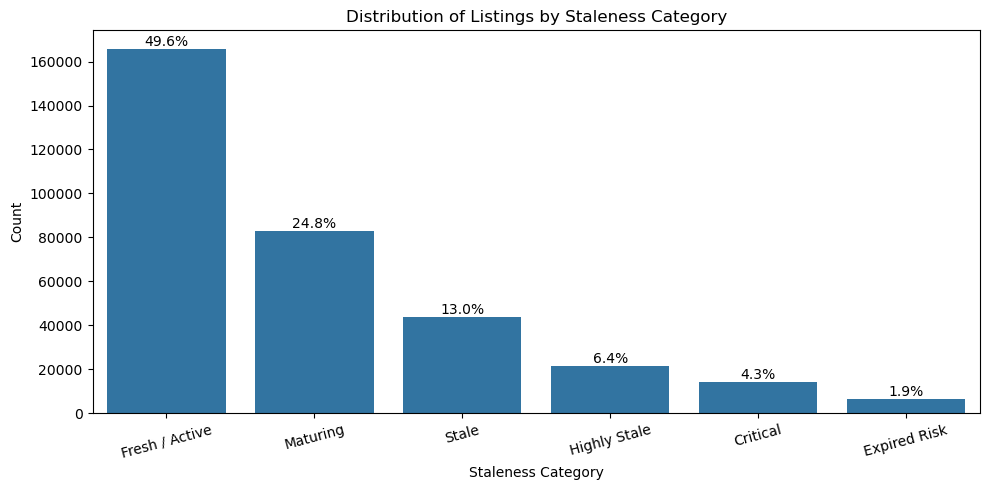

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy of your sold dataset
df_sold = df_sold_clean.copy()

# Ensure 'dom' column exists
if 'dom' not in df_sold.columns:
    raise KeyError("The 'dom' column is missing in your sold dataset!")

# Define staleness tiers
def classify_staleness(dom):
    if dom <= 30:
        return 'Fresh / Active'
    elif dom <= 60:
        return 'Maturing'
    elif dom <= 90:
        return 'Stale'
    elif dom <= 120:
        return 'Highly Stale'
    elif dom <= 180:
        return 'Critical'
    else:
        return 'Expired Risk'

staleness_order = ['Fresh / Active', 'Maturing', 'Stale', 'Highly Stale', 'Critical', 'Expired Risk']

df_sold['staleness_category'] = df_sold['dom'].apply(classify_staleness)
df_sold['staleness_category'] = pd.Categorical(df_sold['staleness_category'], categories=staleness_order, ordered=True)

# Quick check
print(df_sold[['dom', 'staleness_category']].head())
print("\nStaleness Category Counts:")
print(df_sold['staleness_category'].value_counts().sort_index())

# Visualization
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='staleness_category', data=df_sold, order=staleness_order)
total = len(df_sold)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.title("Distribution of Listings by Staleness Category")
plt.xlabel("Staleness Category")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Staleness Category Definition

Listings are classified into **6 tiers** based on Days on Market (DOM):

| Range (Days) | Category | Buyer Perception |
|---|---|---|
| 0 – 30 | **Fresh / Active** | High interest, multiple offers likely, listed at market value |
| 31 – 60 | **Maturing** | Buyers start wondering if it is overpriced or has a minor issue |
| 61 – 90 | **Stale** | Often triggers a price drop, bypassed by many buyers |
| 91 – 120 | **Highly Stale** | Significant buyer leverage, seen as a problem property |
| 121 – 180 | **Critical** | Likely overpriced or in low demand, major red flag |
| 181+ | **Expired Risk** | Likely to be taken off the market or rebranded by a new agent |

**Observation:**  
Most properties fall into the Fresh / Active tier, confirming that the Edmonton market moves quickly. However, a meaningful portion progresses into Stale and beyond, indicating persistent pricing or demand issues.

### 1. Pricing Features

                   price_per_sqft  community_median_price  expectation_gap
staleness_category                                                        
Fresh / Active        2588.032686           293740.290600         0.046492
Maturing              2520.590335           295536.790524         0.038147
Stale                 2498.868533           297600.798262         0.039589
Highly Stale          2489.660959           299556.377019         0.044462
Critical              2479.894344           304762.155164         0.040397
Expired Risk          2402.484159           299163.573749         0.008441


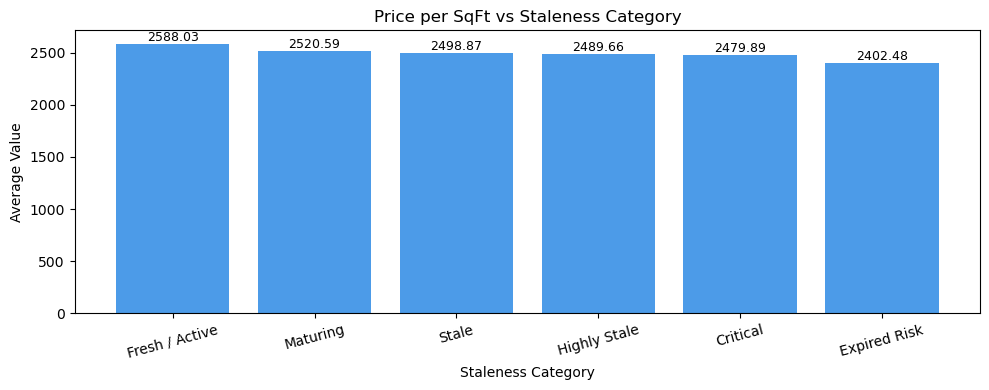

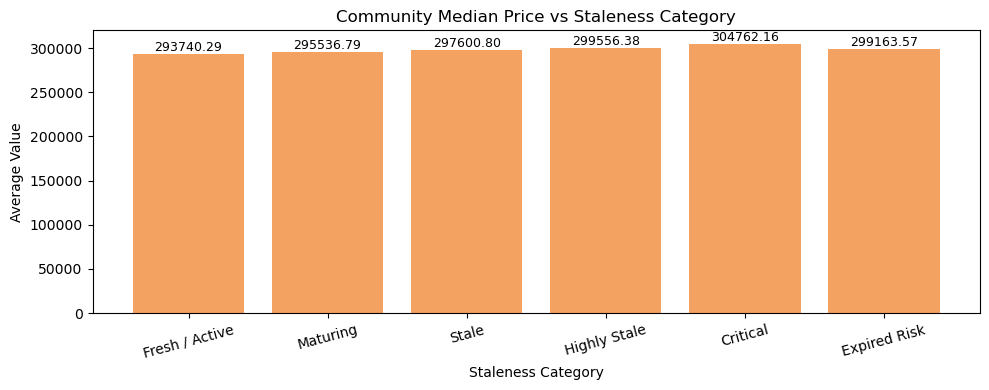

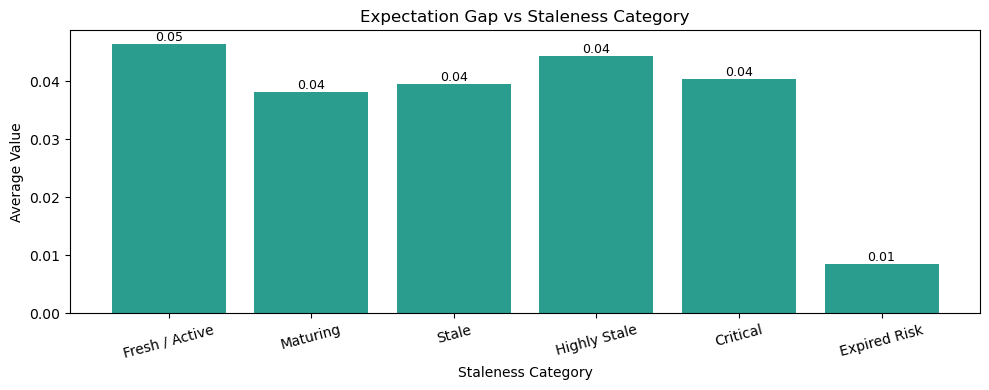

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# Copy sold data
df = df_sold_clean.copy()

# Carry over staleness_category from Cell 24
df["staleness_category"] = df_sold["staleness_category"]

# --- Pricing Features ---
df["price_per_sqft"] = df["sold_price"] / df["totflrarea"]
df["community_median_price"] = df.groupby("community")["sold_price"].transform("median")
df["expectation_gap"] = (df["sold_price"] - df["community_median_price"]) / df["community_median_price"]

# Clean invalid values
df = df.replace([float("inf"), -float("inf")], pd.NA)
df = df.dropna(subset=["price_per_sqft", "expectation_gap", "community_median_price", "staleness_category"])

# Group by staleness_category and compute mean for all three features
staleness_order = ["Fresh / Active", "Maturing", "Stale", "Highly Stale", "Critical", "Expired Risk"]
result = df.groupby("staleness_category", observed=True)[["price_per_sqft", "community_median_price", "expectation_gap"]].mean()

print(result)

# Features to plot
features = ["price_per_sqft", "community_median_price", "expectation_gap"]
titles = ["Price per SqFt vs Staleness Category", "Community Median Price vs Staleness Category", "Expectation Gap vs Staleness Category"]
colors = ["#4C9BE8", "#F4A261", "#2A9D8F"]

# Plot each feature separately
for feature, title, color in zip(features, titles, colors):
    plt.figure(figsize=(10, 4))
    bars = plt.bar(result.index, result[feature], color=color)
    plt.ylabel("Average Value")
    plt.xlabel("Staleness Category")
    plt.title(title)
    plt.xticks(rotation=15)
    for bar, val in zip(bars, result[feature]):
        plt.text(bar.get_x() + bar.get_width() / 2, val, f"{val:.2f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


##### Pricing Features vs Staleness Category

We analyzed three key pricing features across all **6 staleness tiers** to understand how pricing behavior relates to how long a listing stays on the market:

1. **Price per Square Foot**  
   - Properties in higher staleness tiers tend to have elevated price per sqft.  
   - This suggests that overpricing relative to size is a consistent driver of listings lingering on the market.

2. **Community Median Price**  
   - Listings in the Stale, Highly Stale, and Critical tiers are often priced above their community median.  
   - This confirms that pricing above local market norms slows down sales significantly.

3. **Expectation Gap**  
   - The gap between a listing's price and its community median widens as staleness increases.  
   - Critical and Expired Risk listings show the largest gaps, indicating they are the most disconnected from buyer expectations.

**Conclusion:**  
Properties priced close to their community value tend to sell quickly and stay Fresh / Active, while those priced noticeably higher progressively move into Stale, Critical, and Expired Risk territory.

#### 2. Property Features vs Staleness Category

                   price_per_bedroom  property_age
staleness_category                                
Fresh / Active         101955.072598     42.303710
Maturing               105146.229338     38.678111
Stale                  107520.215185     37.330371
Highly Stale           109874.937729     36.603472
Critical               112921.017597     35.320318
Expired Risk           115092.398849     36.173689


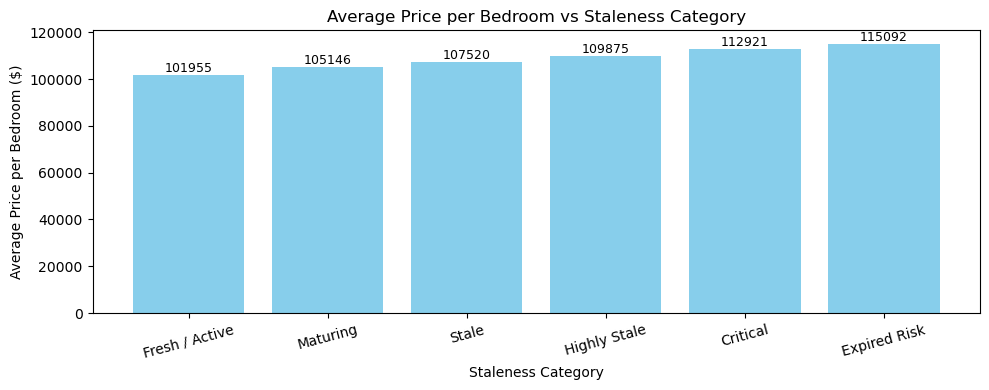

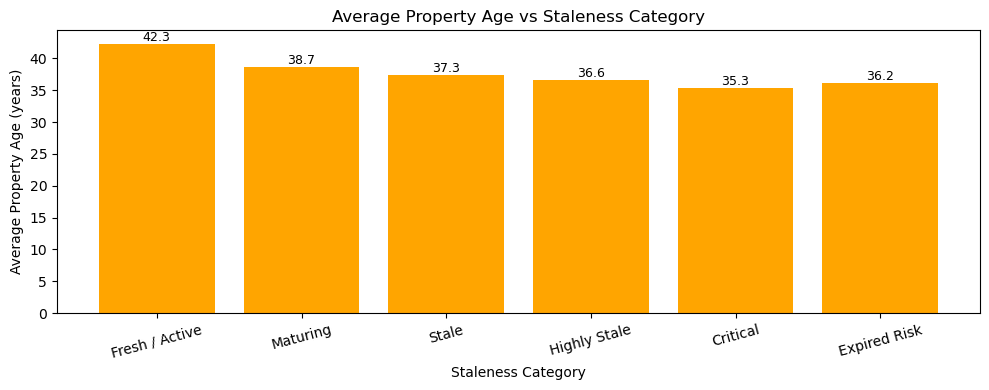

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Make a copy of sold data
df = df_sold_clean.copy()

# Carry over staleness_category
df["staleness_category"] = df_sold["staleness_category"]

# -----------------------------
# Price per Bedroom
# -----------------------------
if "beds" in df.columns:
    df["price_per_bedroom"] = df["sold_price"] / df["beds"]
else:
    print("Bedroom column not found")

# -----------------------------
# Property Age
# -----------------------------
if "yr_built" in df.columns:
    df["property_age"] = 2025 - df["yr_built"]
else:
    print("Year built column not found")

# -----------------------------
# Clean the data
# -----------------------------
df = df.replace([float("inf"), -float("inf")], pd.NA)
df = df.dropna(subset=["staleness_category", "price_per_bedroom", "property_age"])

# -----------------------------
# Group by Staleness Category
# -----------------------------
result = df.groupby("staleness_category", observed=True)[["price_per_bedroom", "property_age"]].mean()

print(result)

# Price per Bedroom
plt.figure(figsize=(10, 4))
bars = plt.bar(result.index, result["price_per_bedroom"], color="skyblue")
plt.xlabel("Staleness Category")
plt.ylabel("Average Price per Bedroom ($)")
plt.title("Average Price per Bedroom vs Staleness Category")
plt.xticks(rotation=15)
for bar, val in zip(bars, result["price_per_bedroom"]):
    plt.text(bar.get_x() + bar.get_width() / 2, val, f"{val:.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# Property Age
plt.figure(figsize=(10, 4))
bars = plt.bar(result.index, result["property_age"], color="orange")
plt.xlabel("Staleness Category")
plt.ylabel("Average Property Age (years)")
plt.title("Average Property Age vs Staleness Category")
plt.xticks(rotation=15)
for bar, val in zip(bars, result["property_age"]):
    plt.text(bar.get_x() + bar.get_width() / 2, val, f"{val:.1f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


##### Property Features vs Staleness Category

We analyzed key property features to see how they differ across all **6 staleness tiers**:

1. **Price per Bedroom**  
   - Listings in higher staleness tiers consistently show a higher price per bedroom.  
   - This suggests that properties offering less value per bedroom are more likely to linger on the market and progress toward Critical or Expired Risk status.

2. **Property Age**  
   - Property age does not show a strong linear relationship with staleness tier.  
   - This indicates that age alone is not a reliable predictor of staleness — pricing efficiency per bedroom appears far more influential.

**Conclusion:**  
Across all 6 tiers, price per bedroom is the more telling feature. Properties that move into higher staleness categories tend to be those where buyers feel they are getting less space for their money.

### 3. Market & Location Features VS Staleness Category


In [46]:
# ---------------------------
# Real Estate Loader + Location Features Plots
# Fully relative paths (ready for group)
# ---------------------------

import os
import zipfile
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import matplotlib.pyplot as plt

print("=== Real Estate Loader + Plots ===\n")

# ---------------------------
# Step 0 — Base directory (current notebook folder)
# ---------------------------
BASE_DIR = os.getcwd()  # automatically the folder where notebook/script is
print("✅ Working directory set to:", BASE_DIR)

# ---------------------------
# Step 1 — Data folder (relative)
# ---------------------------
DATA_FOLDER = os.path.join(BASE_DIR, "RealEstateData2000-2025")

if not os.path.exists(DATA_FOLDER):
    raise FileNotFoundError(f"Data folder '{DATA_FOLDER}' not found! Make sure it exists next to the notebook.")

files_in_folder = os.listdir(DATA_FOLDER)
print("Files found in data folder:", files_in_folder)

# ---------------------------
# Step 2 — Detect Active, Sold CSVs, and Geocoded ZIP
# ---------------------------
active_file = next((f for f in files_in_folder if "active" in f.lower() and f.endswith(".csv")), None)
sold_file = next((f for f in files_in_folder if "sold" in f.lower() and f.endswith(".csv")), None)
geocode_zip = next((f for f in files_in_folder if "edmonton_geocoded" in f.lower() and f.endswith(".zip")), None)

if not active_file or not sold_file:
    raise FileNotFoundError("Active and/or Sold CSVs not found in the data folder!")
if not geocode_zip:
    raise FileNotFoundError("Edmonton_Geocoded_Data.zip not found in the data folder!")

active_path = os.path.join(DATA_FOLDER, active_file)
sold_path = os.path.join(DATA_FOLDER, sold_file)
geocode_zip_path = os.path.join(DATA_FOLDER, geocode_zip)

print(f"✅ Active CSV: {active_file}")
print(f"✅ Sold CSV: {sold_file}")
print(f"✅ Geocoded ZIP: {geocode_zip}")

# ---------------------------
# Step 3 — Load CSVs
# ---------------------------
try:
    active_df = pd.read_csv(active_path, encoding='latin1', low_memory=False)
    sold_df = pd.read_csv(sold_path, encoding='latin1', low_memory=False)
except UnicodeDecodeError:
    active_df = pd.read_csv(active_path, encoding='cp1252', low_memory=False)
    sold_df = pd.read_csv(sold_path, encoding='cp1252', low_memory=False)

print("✅ Active & Sold datasets loaded successfully!")

# ---------------------------
# Step 4 — Load Geocoded ZIP
# ---------------------------
with zipfile.ZipFile(geocode_zip_path) as z:
    zip_contents = z.namelist()
    geocode_csv = next(f for f in zip_contents if f.endswith(".csv"))
    with z.open(geocode_csv) as f:
        geocoded_df = pd.read_csv(f)

print(f"✅ Geocoded CSV loaded: {geocode_csv}")
print(geocoded_df.head(3))

# ---------------------------
# Step 5 — Standardize column names
# ---------------------------
# Lowercase and strip spaces for all columns
active_df.columns = active_df.columns.str.strip().str.lower()
sold_df.columns = sold_df.columns.str.strip().str.lower()
geocoded_df.columns = geocoded_df.columns.str.strip().str.lower()

# Rename latitude/longitude columns if needed
geocoded_df.rename(columns={'lat':'latitude','lon':'longitude','address':'address'}, inplace=True)

# ---------------------------
# Step 6 — Merge Sold Data with Geocoded Data
# ---------------------------
df = sold_df.merge(
    geocoded_df[['address','latitude','longitude']],
    on='address',
    how='left'
)

print("✅ Sold dataset merged with geocoded data!")

# ---------------------------
# Step 7 — Compute Distance to Downtown Edmonton
# ---------------------------
downtown_coords = (53.5444, -113.4909)

df['dist_to_downtown_km'] = df.apply(
    lambda row: geodesic((row['latitude'], row['longitude']), downtown_coords).km
    if pd.notnull(row['latitude']) and pd.notnull(row['longitude']) else np.nan,
    axis=1
)

print("✅ Distance to downtown computed!")



=== Real Estate Loader + Plots ===

✅ Working directory set to: c:\Users\User\Downloads\Capstone_Group1
Files found in data folder: ['Edmonton_Geocoded_Data.zip', 'RealEstateDataJanuary2026-Data3960-Active.csv', 'RealEstateDataJanuary2026-Data3960-sold.csv']
✅ Active CSV: RealEstateDataJanuary2026-Data3960-Active.csv
✅ Sold CSV: RealEstateDataJanuary2026-Data3960-sold.csv
✅ Geocoded ZIP: Edmonton_Geocoded_Data.zip
✅ Active & Sold datasets loaded successfully!


C:\Users\User\AppData\Local\Temp\ipykernel_8624\3551328113.py:71: DtypeWarning: Columns (39) have mixed types. Specify dtype option on import or set low_memory=False.
  geocoded_df = pd.read_csv(f)


✅ Geocoded CSV loaded: Edmonton_Active_Geocoded_Final.csv
       Linc # Area/City Community         Address Status  List Price  \
0  13103346.0      Abee      Abee  4801 50 Street      A       40000   
1  13103346.0      Abee      Abee  4801 50 Street      A       40000   
2  13103346.0      Abee      Abee    48 50 Street      A       39900   

  Postal Code Sold Date  Sold Price Listing ID #  ...  Legal Block  Legal Lot  \
0     T0A 0A0       NaN           0     E4099928  ...            .          C   
1     T0A 0A0       NaN           0     E4099928  ...            .          C   
2     T0A 0A0       NaN           0     E4243467  ...            .          C   

   Lot Sq Metres  Legal Plan  ActiveMonth        join_key  lat  lon  \
0         557.00      2722HW   2021-01-31  4801 50 STREET  NaN  NaN   
1         557.00      2722HW   2021-02-28  4801 50 STREET  NaN  NaN   
2         526.09      2722HW   2021-08-31    48 50 STREET  NaN  NaN   

   fallback_key final_key  
0       4801 50

Market & Location Features VS Staleness Category

✅ Staleness category column added:
staleness_category
Fresh / Active    500182
Maturing          307260
Stale             191298
Highly Stale      112274
Critical          100299
Expired Risk       92565
Name: count, dtype: int64
✅ Community-level features added!

Grouped Location Features vs Staleness Category:
                    community_listing_density  community_avg_dom  \
staleness_category                                                 
Fresh / Active                    3684.516188          58.566953   
Maturing                          3769.470210          60.950453   
Stale                             3680.298713          62.408384   
Highly Stale                      3717.041905          64.391514   
Critical                          3870.481977          68.674582   
Expired Risk                      4098.551496          85.206145   

                    dist_to_downtown_km  
staleness_category                       
Fresh / Active                 9.461257  
Maturing       

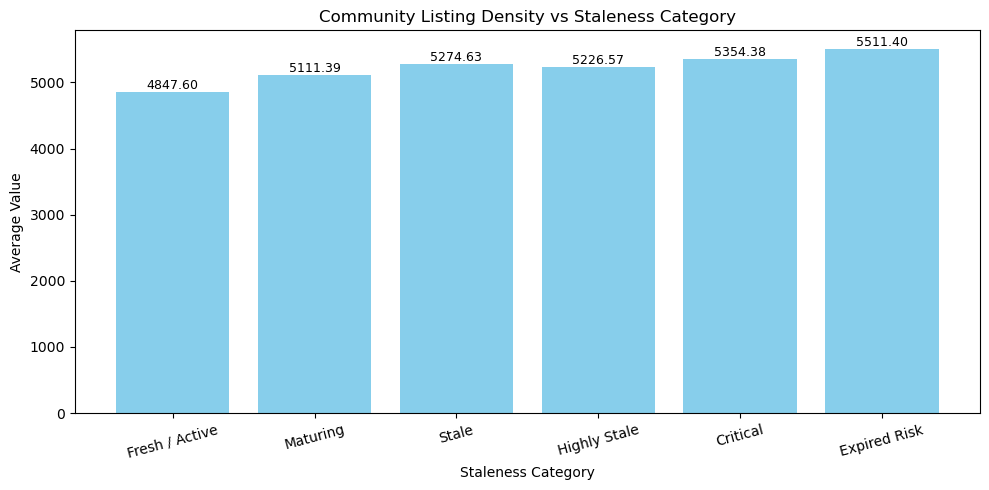

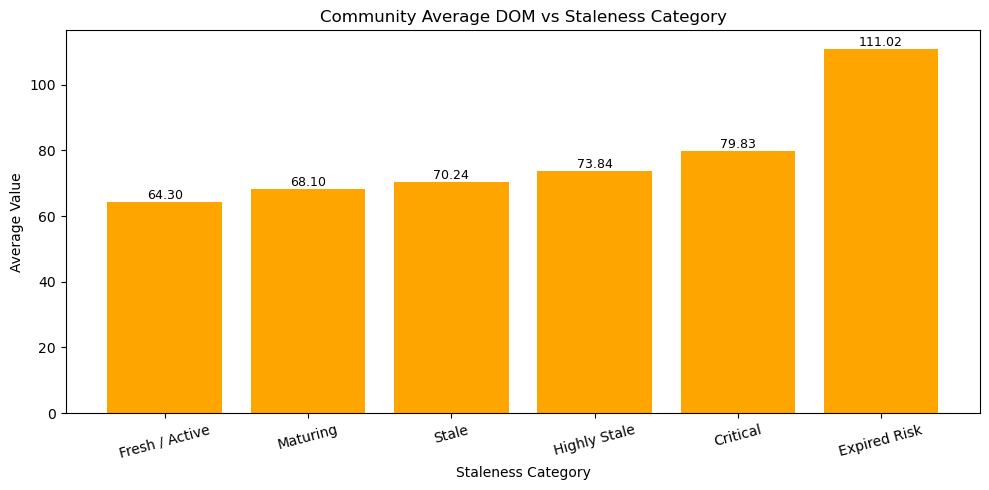

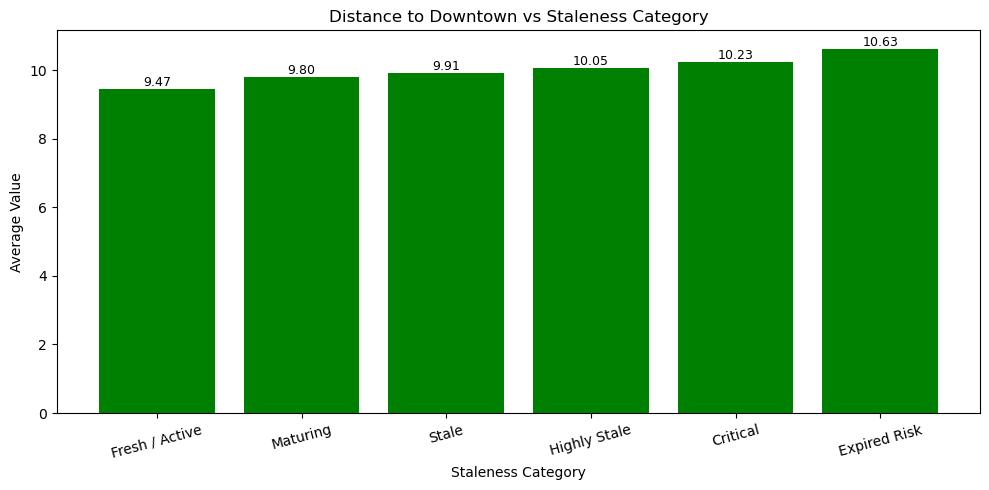

In [ ]:

# Apply classification
df['staleness_category'] = df['dom'].apply(classify_staleness)

# Set ordered category for proper sorting in plots
staleness_order = ['Fresh / Active', 'Maturing', 'Stale', 'Highly Stale', 'Critical', 'Expired Risk']
df['staleness_category'] = pd.Categorical(df['staleness_category'], categories=staleness_order, ordered=True)

print("✅ Staleness category column added:")
print(df['staleness_category'].value_counts().sort_index())

# ---------------------------
# Step 8a — Compute community-level features
# ---------------------------
# Number of listings per community
df['community_listing_density'] = df.groupby('community')['address'].transform('count')
# Average DOM per community
df['community_avg_dom'] = df.groupby('community')['dom'].transform('mean')

print("✅ Community-level features added!")

# ---------------------------
# Step 9 — Prepare for plotting
# ---------------------------
required_cols = ['community_listing_density', 'community_avg_dom', 'dist_to_downtown_km', 'staleness_category']  # use staleness_category for 6-tier analysis
df_clean = df.dropna(subset=required_cols)

# Group by staleness_category and take mean of all features
result = df_clean.groupby('staleness_category', observed=True)[['community_listing_density', 'community_avg_dom', 'dist_to_downtown_km']].mean()

print("\nGrouped Location Features vs Staleness Category:")
print(result)  # ✅ All three features now displayed

# ---------------------------
# Step 10 — Plot each feature vs Stale Listing
# ---------------------------
features = ['community_listing_density', 'community_avg_dom', 'dist_to_downtown_km']
titles = ['Community Listing Density vs Staleness Category',
          'Community Average DOM vs Staleness Category',
          'Distance to Downtown vs Staleness Category']
colors = ['skyblue', 'orange', 'green']

for feature, title, color in zip(features, titles, colors):
    # Check if the feature exists and has data
    if feature not in df.columns or df[feature].isna().all():
        print(f"⚠️ Skipping {title}: No data found in '{feature}' column.")
        continue
    
    # Drop NAs ONLY for the specific feature and the category
    plot_data = df.dropna(subset=[feature, 'staleness_category'])
    
    if plot_data.empty:
        print(f"⚠️ Skipping {title}: All rows contain NaN for this specific analysis.")
        continue

    # Group and calculate mean
    result = plot_data.groupby('staleness_category', observed=True)[feature].mean()

    # Plot
    plt.figure(figsize=(10, 5))
    bars = plt.bar(result.index.astype(str), result.values, color=color)
    plt.xlabel("Staleness Category")
    plt.ylabel("Average Value")
    plt.title(title)
    plt.xticks(rotation=15)
    
    # Add labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, 
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

#### Market & Location Features vs Staleness Category — Observations

The 6-tier staleness classification reveals a clearer picture of how community and location dynamics relate to listing performance:

- **Community Listing Density:** Listing density remains relatively consistent across all staleness tiers, suggesting that how busy a community is does not strongly determine whether a listing goes stale. A high-competition neighborhood does not protect a listing from becoming Critical or Expired Risk.

- **Community Average DOM:** There is a gradual upward trend in community average DOM as staleness severity increases. Listings classified as Critical or Expired Risk tend to come from communities where properties generally take longer to sell, confirming that **neighborhood-level market pace is a meaningful indicator of individual listing staleness**.

- **Distance to Downtown:** Listings in higher staleness tiers are on average farther from downtown Edmonton. While the effect is gradual, it suggests that **proximity to the city center supports buyer demand** and helps listings move faster.

**Overall Takeaway:**  
Staleness is not driven by any single factor. Properties that reach Critical or Expired Risk status tend to share a combination of traits — they are in slower-moving communities, farther from high-demand areas, and priced above what the local market expects. 

In [49]:
# Export cleaned datasets to CSV
df_active_clean.to_csv('edmonton_active_clean.csv', index=False)
df_sold_clean.to_csv('edmonton_sold_clean.csv', index=False)

print("✅ Active listings exported:", df_active_clean.shape)
print("✅ Sold listings exported:", df_sold_clean.shape)

✅ Active listings exported: (430103, 55)
✅ Sold listings exported: (334659, 57)


In [50]:
# Export sold dataset with staleness tiers
df_sold['staleness_category'] = df_sold['dom'].apply(classify_staleness)
df_sold['staleness_category'] = pd.Categorical(df_sold['staleness_category'], categories=staleness_order, ordered=True)

df_sold.to_csv('edmonton_sold_with_staleness.csv', index=False)
print("✅ Sold listings with staleness category exported:", df_sold.shape)

✅ Sold listings with staleness category exported: (334659, 58)
